In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1) (4).zip


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv("IPL.csv", low_memory=False)
print("Dataset shape :", data.shape)
data.head()

Dataset shape : (278205, 64)


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [ ]:
df = data[['match_id','innings','batting_team','bowling_team',
           'over','ball','team_runs','team_wicket',
           'runs_target','city']]

In [ ]:
df = df[df['innings'] == 2]

In [ ]:
df['balls_bowled'] = df['over'] * 6 + df['ball']

In [ ]:
df['balls_left'] = 120 - df['balls_bowled']

In [ ]:
df['runs_left'] = df['runs_target'] - df['team_runs']

In [ ]:
df['wickets_left'] = 10 - df['team_wicket']

In [ ]:
df['current_run_rate'] = (df['team_runs'] / df['balls_bowled']) * 6

In [ ]:
df['required_run_rate'] = (df['runs_left'] / df['balls_left']) * 6

In [ ]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [ ]:
final_state = df.groupby('match_id').tail(1).copy()
final_state['result'] = np.where(final_state['runs_left'] <= 0, 1, 0)
df = df.merge(final_state[['match_id','result']], on='match_id')

In [ ]:
df = df[['batting_team','bowling_team','city',
         'runs_left','balls_left','wickets_left',
         'current_run_rate','required_run_rate','result']]

In [ ]:
df = pd.get_dummies(df, columns=['batting_team','bowling_team','city'])

In [ ]:
X = df.drop('result', axis=1)
y = df['result']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=5000))])

In [ ]:
from sklearn.metrics import accuracy_score
pred = model.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print("Model Accuracy :", accuracy, "≈", round(accuracy*100,2), "%")

Model Accuracy : 0.8134672312361824 ≈ 81.35 %


In [ ]:
def predict_win_probability(batting_team, bowling_team, city,
                            runs_left, balls_left, wickets_left,
                            current_run_rate, required_run_rate):

    input_df = pd.DataFrame({
        'batting_team':[batting_team],
        'bowling_team':[bowling_team],
        'city':[city],
        'runs_left':[runs_left],
        'balls_left':[balls_left],
        'wickets_left':[wickets_left],
        'current_run_rate':[current_run_rate],
        'required_run_rate':[required_run_rate]
    })

    # Encode categorical features
    input_df = pd.get_dummies(input_df)

    # Match training columns
    input_df = input_df.reindex(columns=X_train.columns, fill_value=0)

    probability = model.predict_proba(input_df)

    return probability

In [ ]:
# Extract year
data['year'] = pd.to_datetime(data['date']).dt.year

year = int(input("Enter IPL season year (2008–2025) : "))

if year < 2008 or year > 2025:
    print("Invalid year! Please enter a year between 2008 and 2025.")

else:
    season_data = data[data['year'] == year]

    # Teams that played
    teams = sorted(
        set(season_data['batting_team'].dropna().unique()) |
        set(season_data['bowling_team'].dropna().unique())
    )

    total_matches = season_data['match_id'].nunique()

    start_date = season_data['date'].min()
    end_date = season_data['date'].max()

    # Find final match
    final_match_id = season_data.sort_values('date')['match_id'].iloc[-1]

    final_match = season_data[season_data['match_id'] == final_match_id]

    # Get last ball of each innings
    innings_final = final_match.groupby('innings').tail(1)

    score1 = innings_final.iloc[0]['team_runs']
    score2 = innings_final.iloc[1]['team_runs']

    team1 = innings_final.iloc[0]['batting_team']
    team2 = innings_final.iloc[1]['batting_team']

    # Determine winner
    if score1 > score2:
        season_winner = team1
    else:
        season_winner = team2

    print(f"\nIPL {year} Season Details")
    print("----------------------------")
    print("Season Winner :", season_winner)
    print("Total Matches Played :", total_matches)
    print("Number of Teams :", len(teams))
    print("Season Duration :", start_date, "to", end_date)

    print("\nTeams Participating :")
    for team in teams:
        print(team)

Enter IPL season year (2008–2025) : 2017

IPL 2017 Season Details
----------------------------
Season Winner : Mumbai Indians
Total Matches Played : 59
Number of Teams : 8
Season Duration : 2017-04-05 to 2017-05-21

Teams Participating :
Delhi Daredevils
Gujarat Lions
Kings XI Punjab
Kolkata Knight Riders
Mumbai Indians
Rising Pune Supergiant
Royal Challengers Bangalore
Sunrisers Hyderabad


In [ ]:
batting_team = input("\nEnter Batting Team : ")

if batting_team not in teams:
    print("Invalid team! Please select from the list above.")
else:
    bowling_team = input("Enter Bowling Team : ")

    if bowling_team not in teams:
        print("Invalid team! Please select from the list above.")
    elif bowling_team == batting_team:
        print("Batting and Bowling teams cannot be the same!")


Enter Batting Team : Kings XI Punjab
Enter Bowling Team : Gujarat Lions


In [ ]:
target = int(input("Target score : "))
current_score = int(input("Current score : "))
overs_completed = float(input("Overs completed : "))
wickets_fallen = int(input("Wickets fallen : "))
city = input("Enter City : ")

# convert overs to balls
overs_int = int(overs_completed)
balls_part = int((overs_completed - overs_int) * 10)

balls_bowled = overs_int * 6 + balls_part

balls_left = 120 - balls_bowled
runs_left = target - current_score
wickets_left = 10 - wickets_fallen

# automatic run rate calculations
current_run_rate = current_score / (balls_bowled / 6)
required_run_rate = (runs_left / balls_left) * 6 if balls_left > 0 else 0

Target score : 198
Current score : 23
Overs completed : 6.2
Wickets fallen : 2
Enter City : Gujrat


In [ ]:
if runs_left < 0 or balls_left <= 0 or wickets_left < 0:
    print("Invalid match situation.")
else:
    result = predict_win_probability(
        batting_team,
        bowling_team,
        city,
        runs_left,
        balls_left,
        wickets_left,
        current_run_rate,
        required_run_rate
    )

    batting_win = result[0][1]*100
    bowling_win = result[0][0]*100

    print("\nMatch Prediction")
    print("---------------------")

    print(f"{batting_team} Win Probability : {batting_win:.2f}%")
    print(f"{bowling_team} Win Probability : {bowling_win:.2f}%")


Match Prediction
---------------------
Kings XI Punjab Win Probability : 16.12%
Gujarat Lions Win Probability : 83.88%


In [ ]:
print("\nMatch Situation")
print("---------------------")
print("Runs Left :", runs_left)
print("Balls Left :", balls_left)
print("Wickets Left :", wickets_left)
print(f"Current Run Rate : {current_run_rate:.2f}")
print(f"Required Run Rate : {required_run_rate:.2f}")


Match Situation
---------------------
Runs Left : 175
Balls Left : 82
Wickets Left : 8
Current Run Rate : 3.63
Required Run Rate : 12.80


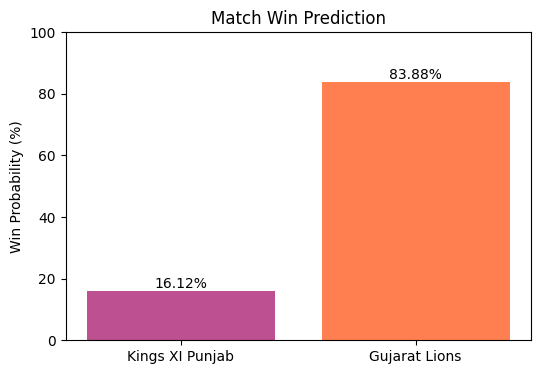

In [ ]:
plt.figure(figsize=(6,4))
teams_plot = [batting_team, bowling_team]
probabilities = [batting_win, bowling_win]
colors = ['#bc5090','#FF7F50']
plt.bar(teams_plot, probabilities, color=colors)
plt.ylabel("Win Probability (%)")
plt.title("Match Win Prediction")
plt.ylim(0,100)
for i,v in enumerate(probabilities):
    plt.text(i, v+1, f"{v:.2f}%", ha='center')
plt.show()